In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
from glob import glob
import scipy.stats
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, precision_score, recall_score

## Combine data

In [2]:
eco_ts_objects = [
    xr.open_dataset(f) for f in
    glob("../data_working/deadtrees/eco_timeseries/*.nc")
]

s1_ts_objects = [
    xr.open_dataset(f) for f in
    glob("../data_working/deadtrees/s1_timeseries/*.nc")
]

ndvi_ts_objects = [
    xr.open_dataset(f) for f in 
    glob("../data_working/deadtrees/ndvi_timeseries/*.nc")
]

In [3]:
# Convert each sensor type into a melted dataframe
eco_concat   = pd.concat([obj.to_dataframe() for obj in eco_ts_objects])\
    .drop(columns=["QC", "spatial_ref", "cloud"])
s1_concat    = pd.concat([obj.to_dataframe() for obj in s1_ts_objects])\
    .drop(columns=["spatial_ref"])
ndvi_concat  = pd.concat([obj.to_dataframe() for obj in ndvi_ts_objects])\
    .drop(columns=["spatial_ref", "ndvi300_qflag"])\
    .rename_axis(index={'geometry': 'sample'})

In [4]:
all_sensors_melt = pd.concat([
    eco_concat.melt(ignore_index=False).dropna(subset=["value"]),
    s1_concat.melt(ignore_index=False).dropna(subset=["value"]),
    ndvi_concat.melt(ignore_index=False).dropna(subset=["value"])
])

In [5]:
all_sensors_melt

variable     value
     time                              
6445 2018-08-19           ESI  0.777889
     2018-08-29           ESI  0.635489
     2018-09-05           ESI  0.511649
     2019-01-30           ESI  0.682318
     2019-02-13           ESI  0.714708
...                       ...       ...
872  2026-05-21  ndvi300_ndvi  0.518000
     2026-06-01  ndvi300_ndvi  0.490000
     2026-06-11  ndvi300_ndvi  0.624000
     2026-06-21  ndvi300_ndvi  0.712000
     2026-07-11  ndvi300_ndvi  0.520000

[1045802 rows x 2 columns]

In [6]:
# Metadata for each dataset id
meta = gpd.read_file("../data_working/deadtrees_aoi.gpkg")
deadwood_over_time = pd.read_csv("../data_working/deadtrees_europe_ann_mean_deadwood.csv")
year_of_max_mort = deadwood_over_time.groupby("dataset_id").apply(lambda x: x["year"][x["deadwood_mean_pct"].idxmax()])

assert all_sensors_melt.index.get_level_values(0).isin(meta["dataset_id"]).all()

/tmp/ipykernel_2783/2571887032.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  year_of_max_mort = deadwood_over_time.groupby("dataset_id").apply(lambda x: x["year"][x["deadwood_mean_pct"].idxmax()])


In [7]:
growing_season = pd.read_parquet("../data_working/deadtrees/aoi_growing_season.parquet")
growing_season["sos_doy"] = growing_season["lsp300_sosd_s1"]
growing_season["eos_doy"] = np.fmin(growing_season["lsp300_eosd_s1"], growing_season["lsp300_eosd_s2"])
growing_season = growing_season[["sos_doy", "eos_doy"]]
growing_season = growing_season.reset_index()

In [8]:
all_sensors_melt["obs_year"] = all_sensors_melt.index.get_level_values("time").year
all_sensors_melt["obs_doy"] = all_sensors_melt.index.get_level_values("time").dayofyear
all_sensors_melt = all_sensors_melt.reset_index()

In [9]:
all_sensors_melt = pd.merge(
    all_sensors_melt,
    growing_season,
    left_on=[all_sensors_melt["level_0"], all_sensors_melt.obs_year],
    right_on=[growing_season["geometry"], growing_season["time"].dt.year]
).drop(columns=["key_0", "key_1", "level_0", "time_y"]).set_index(["geometry", "variable"])

all_sensors_melt

time_x     value  obs_year  obs_doy     sos_doy  \
geometry variable                                                           
6445     ESI          2018-08-19  0.777889      2018      231  116.375000   
         ESI          2018-08-29  0.635489      2018      241  116.375000   
         ESI          2018-09-05  0.511649      2018      248  116.375000   
         ESI          2019-01-30  0.682318      2019       30  121.500000   
         ESI          2019-02-13  0.714708      2019       44  121.500000   
...                          ...       ...       ...      ...         ...   
872      ndvi300_ndvi 2025-07-11  0.594000      2025      192  184.833328   
         ndvi300_ndvi 2025-08-01  0.634000      2025      213  184.833328   
         ndvi300_ndvi 2025-11-01  0.722000      2025      305  184.833328   
         ndvi300_ndvi 2025-11-21  0.720000      2025      325  184.833328   
         ndvi300_ndvi 2025-12-01  0.694000      2025      335  184.833328   

                       eos_doy  
geometry variable               
6445     ESI           296.750  
         ESI           296.750  
         ESI           296.750  
         ESI           299.125  
         ESI           299.125  
...                        ...  
872      ndvi300_ndvi  306.000  
         ndvi300_ndvi  306.000  
         ndvi300_ndvi  306.000  
         ndvi300_ndvi  306.000  
         ndvi300_ndvi  306.000  

[985257 rows x 6 columns]

In [10]:
# Drop observations outside growing season
all_sensors_filter = all_sensors_melt[
    (all_sensors_melt.obs_doy >= all_sensors_melt.sos_doy) &
    (all_sensors_melt.obs_doy <= all_sensors_melt.eos_doy)
].rename(columns=dict(time_x="time"))

In [11]:
# Attach metadata - acquisition year and mortality category
all_sensors_filter = all_sensors_filter.join(
    meta[["dataset_id", "acquisition_year", "aoi_area", "deadwood_area"]].set_index("dataset_id"),
    on="geometry"
)

In [12]:
# Aggregate annual mean of NDVI, ESI, and VH backscatter
all_sensors_filter["year_of_max_mort"] = year_of_max_mort.align(all_sensors_filter, level="geometry")[0]
all_sensors_filter["obs_year_rel"] = all_sensors_filter["obs_year"] - all_sensors_filter["year_of_max_mort"]
all_sensors_filter["severity"] = all_sensors_filter["deadwood_area"] / all_sensors_filter["aoi_area"]

ann_summary = all_sensors_filter.dropna(subset=["year_of_max_mort"]).query('variable in ["ESI", "ndvi300_ndvi", "VH"]')\
    .groupby(["geometry", "obs_year_rel", "variable"]).agg({
    "value": "mean",
    "severity": lambda x: x.iloc[0]
})

In [13]:
ann_summary

value  severity
geometry obs_year_rel variable                        
207      -9.0         VH            0.038234  0.009692
                      ndvi300_ndvi  0.716396  0.009692
         -8.0         VH            0.047639  0.009692
                      ndvi300_ndvi  0.741026  0.009692
         -7.0         VH            0.043513  0.009692
...                                      ...       ...
10425     5.0         VH            0.046511  0.006079
                      ndvi300_ndvi  0.818967  0.006079
          6.0         ESI           0.681125  0.006079
                      VH            0.041713  0.006079
                      ndvi300_ndvi  0.818593  0.006079

[4222 rows x 2 columns]

In [14]:
# silence small sample warnings from theilsen
import warnings
warnings.filterwarnings("ignore", message=".*sample arguments is too small.*")
warnings.filterwarnings("ignore", message=".*mean of empty slice.*")

In [15]:
# Apply transformations 
# convert SAR backscatter to DB
VH_sigma0 = ann_summary.loc[pd.IndexSlice[:, :, "VH"], "value"]
VH_sigma0_db = 10 * np.log10(VH_sigma0)
ann_summary.loc[pd.IndexSlice[:, :, "VH"], "value"] = VH_sigma0_db

/srv/conda/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [16]:
# Standardize SAR backscatter and NDVI to account for cover being a
# confounding variable between mort and non-mort groups
def robust_std(x: pd.Series):
    '''
    Standardize `x` as (x - median(x)) / IQR.
    '''
    return (x - x.median()) / (x.quantile(0.75) - x.quantile(0.25))

for var in ["VH", "ndvi300_ndvi"]:
    x = ann_summary.loc[pd.IndexSlice[:, :, var], "value"]
    x_std = x.groupby("geometry", group_keys=False).apply(lambda x: (x - x.mean()) / x.std())
    to_append = pd.DataFrame({
        "value": x_std.reset_index(drop=True),
        "severity": ann_summary.loc[pd.IndexSlice[:, :, var], "severity"].reset_index(drop=True)
    }).set_index(x.rename(index={var:var+"_std"}).index)
    ann_summary = pd.concat([ann_summary, to_append])

In [17]:
ann_summary = ann_summary.sort_index()
ann_summary["mort_group"] = np.where(ann_summary["severity"] > 0.05, "mort", "non-mort")

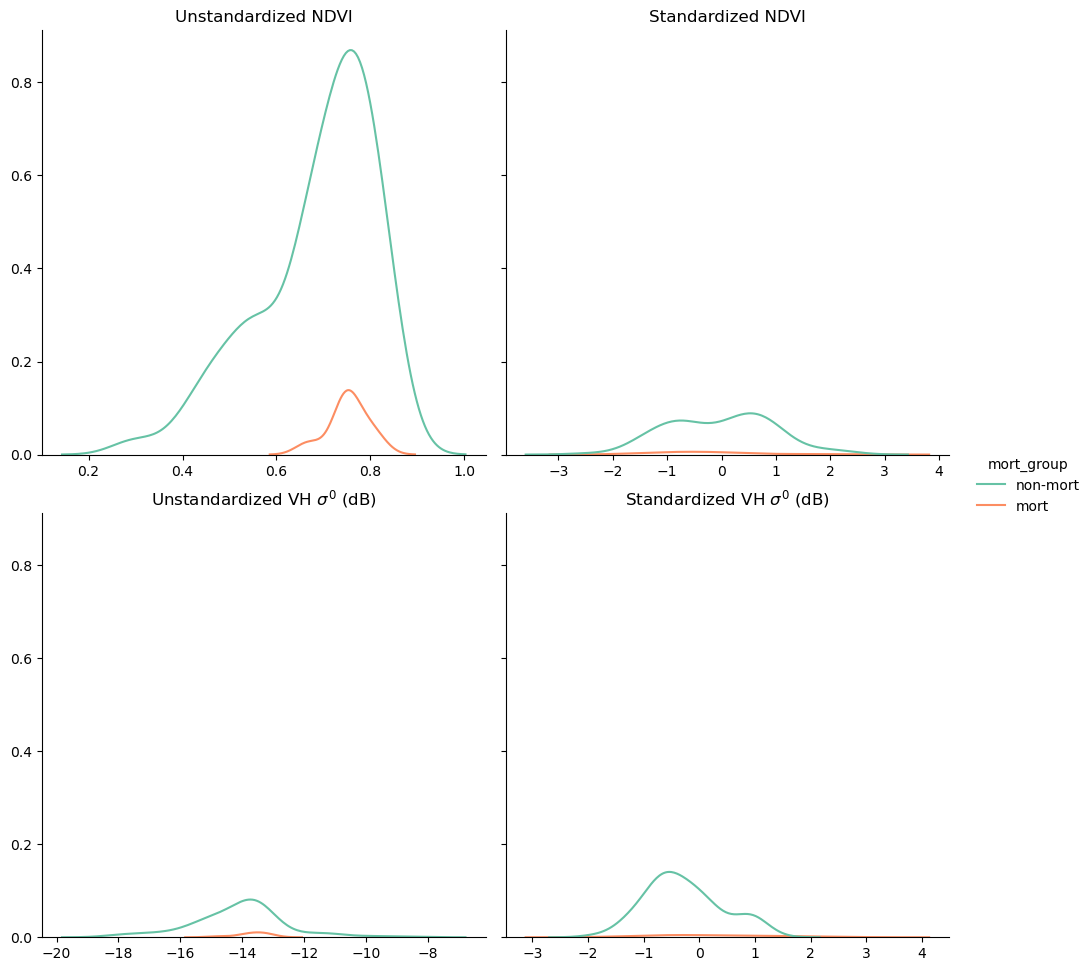

In [18]:
facet = sns.displot(
    data=ann_summary.loc[:, 0, ["ndvi300_ndvi", "ndvi300_ndvi_std", "VH", "VH_std"]], 
    x='value',
    hue="mort_group",
    col='variable', kind='kde', col_wrap=2,
    facet_kws=dict(sharex=False),
    palette={"mort":"#fc8d62", "non-mort":"#66c2a5"} 
)

plt.gcf().supxlabel("")
facet.set_axis_labels("", "")
facet.axes.flat[0].set_title("Unstandardized NDVI")
facet.axes.flat[1].set_title("Standardized NDVI")
facet.axes.flat[2].set_title("Unstandardized VH $\\sigma^0$ (dB)")
facet.axes.flat[3].set_title("Standardized VH $\\sigma^0$ (dB)")
plt.show()

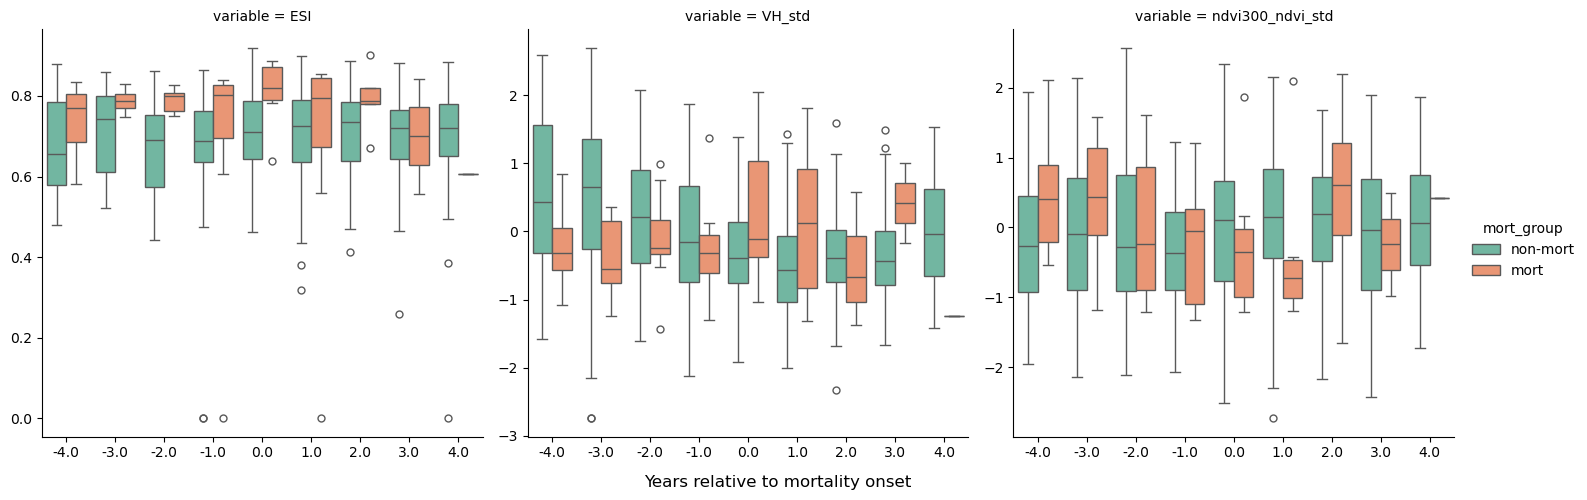

In [19]:
facet = sns.catplot(
    data=ann_summary.loc[:, slice(-4, 4), ["ndvi300_ndvi_std", "VH_std", "ESI"]], 
    x='obs_year_rel', y='value',
    hue="mort_group",
    sharex=True, sharey=False,
    col='variable', kind='box', col_wrap=3,
    palette={"mort":"#fc8d62", "non-mort":"#66c2a5"} 
)

plt.gcf().supxlabel("Years relative to mortality onset")
facet.set_axis_labels("", "")
#facet.axes[0].set_title("Standardized VH backscatter (dB)")
#facet.axes[1].set_title("Standardized NDVI")
plt.show()

In [20]:
# Run linear regressions - do we see change about mortality onset?
for var in ["ndvi300_ndvi", "VH", "ESI"]:
    print(var)
    subset = ann_summary.loc[:, slice(-4, 4), var]
    
    for group, data in subset.groupby("mort_group"):
        data = data.dropna()
        mod = sm.OLS(data["value"], data.index.get_level_values("obs_year_rel")).fit()
        print(group)
        print(mod.f_pvalue)
        print(mod.params)
        print(mod.conf_int())

ndvi300_ndvi
mort
0.002213399963392891
x1   -0.129653
dtype: float64
           0         1
x1 -0.210582 -0.048724
non-mort
0.20210959236176684
x1   -0.011024
dtype: float64
          0         1
x1 -0.02797  0.005923
VH
mort
0.0029455287826846807
x1    2.296505
dtype: float64
           0        1
x1  0.817629  3.77538
non-mort
0.5007732732623302
x1   -0.119921
dtype: float64
           0         1
x1 -0.469301  0.229458
ESI
mort
0.021864234212379714
x1   -0.110874
dtype: float64
           0         1
x1 -0.204894 -0.016853
non-mort
1.9142905064034231e-29
x1    0.125462
dtype: float64
           0         1
x1  0.104639  0.146285


In [21]:
ann_summary.loc[:, 0, "ndvi300_ndvi_std"]["value"].isnull().value_counts()

value
False    136
Name: count, dtype: int64

In [22]:
ann_summary.loc[:, 0, :].groupby("variable")["mort_group"].apply(lambda x: (x == "mort").sum() / x.shape[0])

variable
ESI                 0.056604
VH                  0.057143
VH_std              0.057143
ndvi300_ndvi        0.058824
ndvi300_ndvi_std    0.058824
Name: mort_group, dtype: float64

ndvi300_ndvi_std
TtestResult(statistic=-0.6177557588005947, pvalue=0.27709737812709834, df=7.866248909908639)
ConfidenceInterval(low=-inf, high=0.44654754193057355)
134
Precision: 0.000
Recall: 0.000
VH_std
TtestResult(statistic=1.423685421811133, pvalue=0.9022921270162899, df=7.379235545432055)
ConfidenceInterval(low=-inf, high=1.2445533913258209)
138
Precision: 0.000
Recall: 0.000
ESI
TtestResult(statistic=2.5267895914818923, pvalue=0.9767668661267566, df=5.7636649355384115)
ConfidenceInterval(low=-inf, high=0.17397606825119533)
105
Precision: 0.000
Recall: 0.000


/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


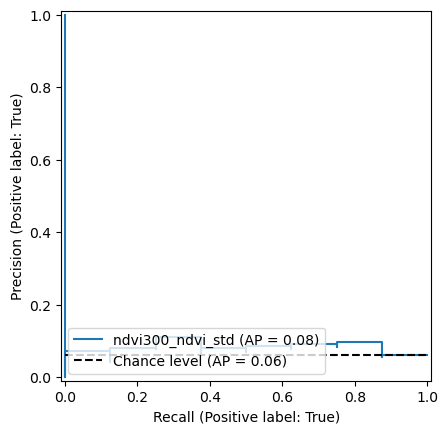

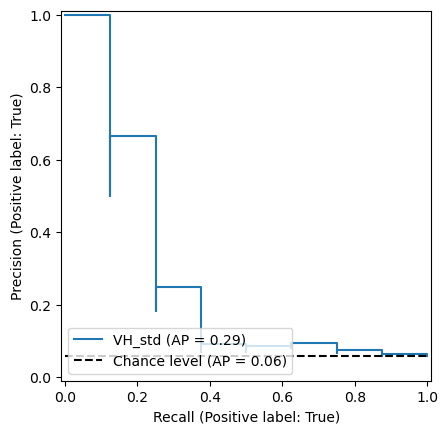

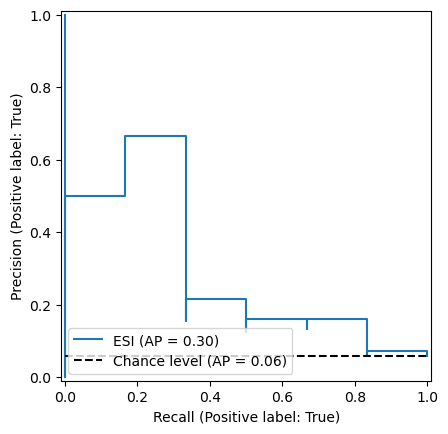

In [23]:
for var in ["ndvi300_ndvi_std", "VH_std", "ESI"]:
    print(var)
    subset = ann_summary.loc[:, 0, var].dropna()

    x_mort    = subset["value"][subset["mort_group"] == "mort"]
    x_nonmort = subset["value"][subset["mort_group"] == "non-mort"]
    test = scipy.stats.ttest_ind(x_mort, x_nonmort, equal_var=False, alternative="less")
    print(test)
    print(test.confidence_interval())
    
    y = subset["mort_group"] == "mort"
    x = subset[["value"]]
    
    logreg = LogisticRegression()
    logreg.fit(x, y)
    print(x.shape[0])
    print(f"Precision: {precision_score(y, logreg.predict(x)):.3f}")
    print(f"Recall: {recall_score(y, logreg.predict(x)):.3f}")


    PrecisionRecallDisplay.from_estimator(logreg, x, y, plot_chance_level=True, name=var)

In [24]:
ann_summary.to_parquet("../data_working/ann_summary_deadtrees.parquet")

### Power spectrum analysis

In [25]:
obs_range = ann_summary.reset_index().groupby("geometry")["obs_year_rel"].agg(["min", "max"])
obs_range["range"] = obs_range["max"] - obs_range["min"]
usable_ts = obs_range[
    (obs_range["min"] <= -1) &
    (obs_range["max"] >= 1) &
    (obs_range["range"] >= 8)
]

In [26]:
all_sensors_melt

time_x     value  obs_year  obs_doy     sos_doy  \
geometry variable                                                           
6445     ESI          2018-08-19  0.777889      2018      231  116.375000   
         ESI          2018-08-29  0.635489      2018      241  116.375000   
         ESI          2018-09-05  0.511649      2018      248  116.375000   
         ESI          2019-01-30  0.682318      2019       30  121.500000   
         ESI          2019-02-13  0.714708      2019       44  121.500000   
...                          ...       ...       ...      ...         ...   
872      ndvi300_ndvi 2025-07-11  0.594000      2025      192  184.833328   
         ndvi300_ndvi 2025-08-01  0.634000      2025      213  184.833328   
         ndvi300_ndvi 2025-11-01  0.722000      2025      305  184.833328   
         ndvi300_ndvi 2025-11-21  0.720000      2025      325  184.833328   
         ndvi300_ndvi 2025-12-01  0.694000      2025      335  184.833328   

                       eos_doy  
geometry variable               
6445     ESI           296.750  
         ESI           296.750  
         ESI           296.750  
         ESI           299.125  
         ESI           299.125  
...                        ...  
872      ndvi300_ndvi  306.000  
         ndvi300_ndvi  306.000  
         ndvi300_ndvi  306.000  
         ndvi300_ndvi  306.000  
         ndvi300_ndvi  306.000  

[985257 rows x 6 columns]

In [27]:
usable_ndvi_ts = all_sensors_melt.loc[(usable_ts.index.tolist(), "ndvi300_ndvi"), :]

In [28]:
usable_ndvi_ts = pd.merge(
    usable_ndvi_ts,
    meta.drop(columns=["authors", "bbox", "biome_name", "forest_cover_quality", "license", "platform"]),
    left_on="geometry",
    right_on="dataset_id"
)

In [29]:
from scipy.signal import spectrogram, detrend

def spectral_power(obs_time: pd.Series, value: pd.Series, mort_year: int, sample_period: int=10, **spec_kwargs):
    # Convert obs dt to days since Y2K
    zero_date = pd.to_datetime(f"{mort_year}-01-01")
    x_epoch = (obs_time - zero_date) / pd.Timedelta(days=1)
    # Detrend the timeseries
    y_detrend = detrend(value)

    # Resample to constant sample frequency
    x_new = np.arange(x_epoch.min(), x_epoch.max(), sample_period)
    y_new = np.interp(x_new, x_epoch, y_detrend)

    # Spectrogram
    sample_freq = 1/sample_period
    f, t, Sxx = spectrogram(y_new, sample_freq, nperseg=32, noverlap=16, scaling="spectrum", **spec_kwargs)
    t_asdate = zero_date + pd.to_timedelta(t + x_new.min(), unit="days")

    # Sum frequencies with period longer than 100 days
    Sxx_sum = Sxx[f < 0.01].sum(axis=0)

    return t_asdate, Sxx_sum

In [30]:
def spectral_power_driver(df: pd.DataFrame):
    mort_year = df.acquisition_year.iloc[0]
    t_asdate, smax = spectral_power(df["time_x"], df["value"], mort_year)
    smax_rel = smax / smax.max()
    
    t_rel = (t_asdate - pd.to_datetime(f"{mort_year}-01-01")) / pd.Timedelta(days=1)
    # Relative spectral power at mortality start
    smax_rel_at_mort = np.interp(0, t_rel, smax_rel)

    # Trend in spectral power leading up to mortality
    pre_mort_mask = (t_rel < 0) & (t_rel > -1500)
    if pre_mort_mask.sum() < 5:
        smax_trend_pre_mort = np.nan
    else:
        smax_trend_pre_mort = np.polyfit(t_rel[pre_mort_mask], smax_rel[pre_mort_mask], 1)[0]
    
    ret = pd.Series(dict(
        mort_group="mort" if df.deadwood_area.iloc[0] / df.aoi_area.iloc[0] > 0.05 else "non-mort",
        onset_year=mort_year,
        rel_smax_at_onset=smax_rel_at_mort,
        smax_trend_at_onset=smax_trend_pre_mort
    ))

    return ret

In [31]:
ndvi_power_at_onset = usable_ndvi_ts.groupby("geometry").apply(spectral_power_driver)

/tmp/ipykernel_620/3225257272.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ndvi_power_at_onset = usable_ndvi_ts.groupby("geometry").apply(spectral_power_driver)


<Axes: xlabel='smax_trend_at_onset', ylabel='Count'>

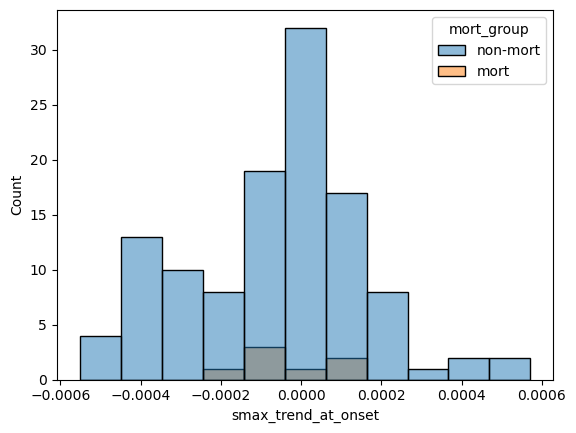

In [32]:
sns.histplot(
    ndvi_power_at_onset,
    x="smax_trend_at_onset",
    hue="mort_group"
)

In [33]:
import scipy.stats

In [34]:
mort_rel_smax = ndvi_power_at_onset.query("mort_group == 'mort'")["smax_trend_at_onset"].dropna()
nonmort_rel_smax = ndvi_power_at_onset.query("mort_group == 'non-mort'")["smax_trend_at_onset"].dropna()
scipy.stats.ttest_ind(mort_rel_smax, nonmort_rel_smax, alternative="less")

TtestResult(statistic=0.32617426001702154, pvalue=0.6275720157771068, df=121.0)

In [35]:
mort_rel_smax = ndvi_power_at_onset.query("mort_group == 'mort'")["rel_smax_at_onset"].dropna()
nonmort_rel_smax = ndvi_power_at_onset.query("mort_group == 'non-mort'")["rel_smax_at_onset"].dropna()
scipy.stats.ttest_ind(mort_rel_smax, nonmort_rel_smax, alternative="less")

TtestResult(statistic=-0.8844793322142578, pvalue=0.1890678188804285, df=125.0)

In [36]:
y = ndvi_power_at_onset["mort_group"] == "mort"
x = ndvi_power_at_onset[["rel_smax_at_onset"]]

logreg = LogisticRegression()
logreg.fit(x, y)
print(x.shape[0])
print(f"Precision: {precision_score(y, logreg.predict(x)):.3f}")
print(f"Recall: {recall_score(y, logreg.predict(x)):.3f}")

127
Precision: 0.000
Recall: 0.000


/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [42]:
ndvi_power_at_onset.reset_index(drop=True).to_parquet("../data_working/power_at_onset_deadtrees.parquet")